In [ ]:
"""
滑珠图
"""

[1, 1, 1, 1, 1]
[1.2483231305468498, 1.0381725900335999, 1.2599269183922046, 1.1924789436743288, 1.063809673861667]
[1.1686535250871386, 1.4492570157588378, 1.195006090133983, 1.2940318476925776, 1.5445092169528911]
[1.3433115608798805, 1.4748237187071127, 1.2713763702801462, 1.457678978768205, 1.7182921065070111]


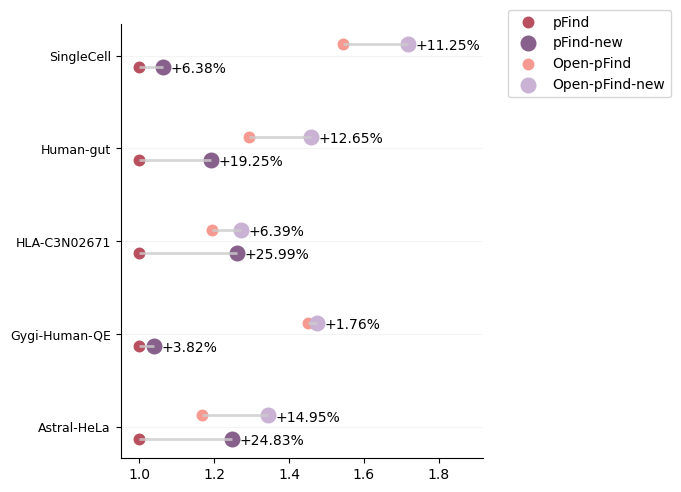

In [26]:
import os
import matplotlib.pyplot as plt
import numpy as np

def get_target_info(summary_path):
    f = open(summary_path,"r")
    peptide_num = int(f.readlines()[3].strip().split(": ")[-1])
    # for line in f:
    #     if line.startswith("Overall"):
    #         id_rate = float(line.strip("%\n").split(" ")[-1])
    #         break
    f.close()
    # return id_rate
    return peptide_num
        
# # ===================== 1. 准备数据（可替换为自己的数据） =====================
# # 示例：5个类别，每组类别对应2个对比数据（如“干预前”和“干预后”）
# names = ["9Apis", "9Bacillus", 
#          "9Bacteria", 
#          "9Human", 
#          "9Mouse", 
#          # "9Met", 
#          # "9Cere", "9Sol", "9Vigna"
#         ]
# new_dir = "G:/pFindWorkspace/9species/new/"
# ori_dir = "G:/pFindWorkspace/9species/ori/"
# categories = ["Apis-mellifera",  # 9Apis  西方蜜蜂
#               "Bacillus-subtilis", # 9Bacillus  枯草芽孢杆菌
#               "Candidatus-endoloripes",  # 9Bacteria  内隐念珠菌
#               "Human",  # 9Human
#               "Mus-musculus",  # 9Mouse  小家鼠
#               # "Methanosarcina-mazei",  # 9Met  马氏甲烷八叠球菌
#               # "Saccharomyces-cerevisiae",  # 9Cere  酿酒酵母
#               # "Solanum-lycopersicum",  # 9Sol  番茄
#               # "Vigna-radiata"
#              ]  # 9Vigna  绿豆

# """
# Peptide Level:
# Spectra: 565810
# Scans: 434791
# Peptides: 62799
# Sequences: 44512
# Proteins: 8094
# """
# data_new = list()
# data_ori = list()
# for name in names:
#     summary_path = os.path.join(new_dir, name, "result", "restricted-1029", "pFind.summary")
#     data_new.append(get_target_info(summary_path))
#     summary_path = os.path.join(ori_dir, name, "result", "restricted-1029", "pFind.summary")
#     data_ori.append(get_target_info(summary_path))    
# data_new_open = list()
# data_ori_open = list()
# for name in names:
#     summary_path = os.path.join(new_dir, name, "result", "pFind.summary")
#     data_new_open.append(get_target_info(summary_path))
#     summary_path = os.path.join(ori_dir, name, "result", "pFind.summary")
#     data_ori_open.append(get_target_info(summary_path))




categories = ["Astral-HeLa", "Gygi-Human-QE", "HLA-C3N02671", "Human-gut", "SingleCell"]
data_ori = [34141, 169048, 16420, 91184, 25388]   # 32054
data_new = [42619, 175501, 20688, 108735, 27008]
data_ori_open = [39899, 244994, 19622, 117995, 39212]
data_new_open = [45862, 249316, 20876, 132917, 43624]
for i in range(len(data_ori)):
    data_new_open[i] /= data_ori[i]
    data_ori_open[i] /= data_ori[i]
    data_new[i] /= data_ori[i]
    data_ori[i] = 1
print(data_ori)
print(data_new)
print(data_ori_open)
print(data_new_open)
# 为了让分类标签垂直排列更整齐，对类别进行编号（y轴位置）
y_pos = np.arange(len(categories))*4
y_pos_open = y_pos + 1

colors = ['#C9B2D4','#F69990','#87608B','#B9505F']
# ===================== 2. 创建哑铃图 =====================
plt.figure(figsize=(7, 5))  # 设置图大小
ax = plt.gca()  # 获取当前坐标轴

# 1. 画哑铃中间的连线（核心：连接每组的两个数据点）
ax.hlines(
    y=y_pos,  # 连线的y轴位置（对应每个类别）
    xmin=data_ori,  # 连线左端x值（第一组数据）
    xmax=data_new,  # 连线右端x值（第二组数据）
    color="#cccccc",  # 连线颜色（灰色，避免抢焦点）
    linewidth=2,  # 连线粗细
    alpha=0.8  # 透明度
)

ax.hlines(
    y=y_pos_open,  # 连线的y轴位置（对应每个类别）
    xmin=data_ori_open,  # 连线左端x值（第一组数据）
    xmax=data_new_open,  # 连线右端x值（第二组数据）
    color="#cccccc",  # 连线颜色（灰色，避免抢焦点）
    linewidth=2,  # 连线粗细
    alpha=0.8  # 透明度
)

ax.scatter(
    data_ori, y_pos,
    color=colors[3],  # 红色：区分第一组
    s=50,  # 点的大小
    marker="o",  # 圆形标记
    # edgecolor="white",  # 白色边框：让点更清晰
    label="pFind",
    linewidth=1.5
)
ax.scatter(
    data_new, y_pos,
    color=colors[2],  # 蓝色：区分第二组
    s=100,
    marker="o",
    # edgecolor="white",
    label="pFind-new",
    linewidth=1.5
)

ax.scatter(
    data_ori_open, y_pos_open,
    color=colors[1],  # 红色：区分第一组
    s=50,  # 点的大小
    marker="o",  # 圆形标记
    # edgecolor="white",  # 白色边框：让点更清晰
    label="Open-pFind",
    linewidth=1.5
)
ax.scatter(
    data_new_open, y_pos_open,
    color=colors[0],  # 蓝色：区分第二组
    s=100,
    marker="o",
    # edgecolor="white",
    label="Open-pFind-new",
    linewidth=1.5
)
for i, (dn, doo, dno) in enumerate(zip(data_new, data_ori_open, data_new_open)):
    ax.text(dn+0.02, i*4-0.25, f"+{dn*100-100:.2f}%")
    ax.text(dno+0.02, i*4+0.75, f"+{dno/doo*100-100:.2f}%")

# ===================== 3. 优化图表样式 =====================
# 设置y轴标签（类别名称）
ax.set_yticks(y_pos+0.5)
ax.set_yticklabels(categories, fontsize=9)

# 设置x轴标签和标题
ax.set_xlabel("", fontsize=12)
ax.set_ylabel("", fontsize=12)
ax.set_title("", fontsize=14, pad=20)

# 调整x轴范围（留一点余量，避免点贴边）
x_min = min(min(data_ori), min(data_new_open))
x_max = max(max(data_ori), max(data_new_open))
ax.set_xlim(x_min-0.05, x_max+0.2)

# 隐藏顶部和右侧边框（让图表更简洁）
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# 添加网格线（辅助读值）
ax.grid(axis="y", color="#f0f0f0", linestyle="-", alpha=0.7)
# ax.set_xscale('log',base=np.e)

# 调整布局
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1.05))
plt.tight_layout()

# 显示或保存图表
plt.show()
# plt.savefig("哑铃图.png", dpi=300, bbox_inches="tight")  # 保存为高清图片

[1, 1, 1, 1, 1, 1, 1, 1, 1]
[1.0607014022620629, 1.0373318111391991, 1.0186600564621635, 1.0342615651648932, 1.1050728731216812, 1.0122342762513097, 1.0393579439030751, 1.0100470310908696, 1.053861071932299]
[1.7223683853643983, 2.817793362146294, 1.265647593472423, 1.9265715795034337, 1.4209693819907354, 4.9022609753624655, 2.3167603196054722, 1.24499650985822, 2.8804213681241184]
[2.021996799479237, 3.230074206964038, 1.532052606210838, 2.126330088295223, 1.5824200655293188, 5.803812227516983, 2.57870403300377, 1.2785934156472782, 3.245019393511989]


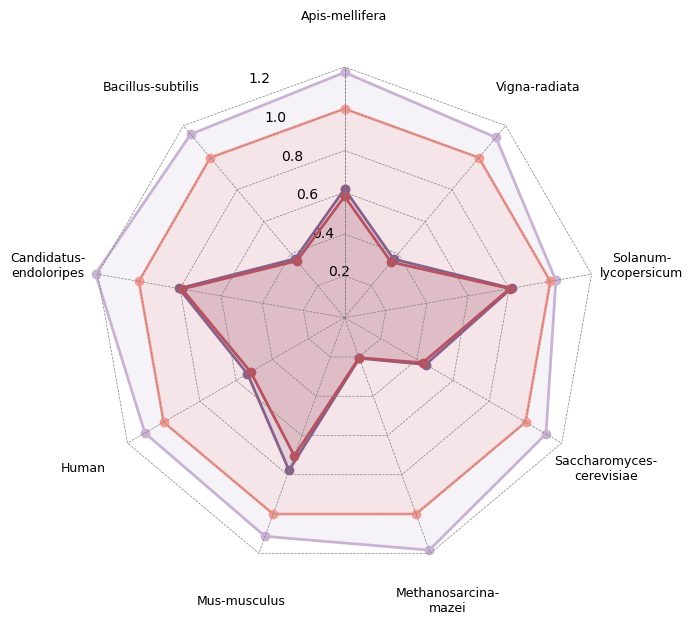

In [260]:
import os
import matplotlib.pyplot as plt
import numpy as np
from math import pi

def get_target_info(summary_path):
    f = open(summary_path,"r")
    peptide_num = int(f.readlines()[3].strip().split(": ")[-1])
    # for line in f:
    #     if line.startswith("Overall"):
    #         id_rate = float(line.strip("%\n").split(" ")[-1])
    #         break
    f.close()
    # return id_rate
    return peptide_num
        
# ===================== 1. 准备数据（可替换为自己的数据） =====================
# 示例：5个类别，每组类别对应2个对比数据（如“干预前”和“干预后”）
names = ["9Apis", "9Bacillus", 
         "9Bacteria", 
         "9Human", 
         "9Mouse", 
         "9Met", 
         "9Cere", "9Sol", "9Vigna"
        ]
new_dir = "G:/pFindWorkspace/9species/new/"
ori_dir = "G:/pFindWorkspace/9species/ori/"
categories = ["Apis-mellifera",  # 9Apis  西方蜜蜂
              "Bacillus-subtilis", # 9Bacillus  枯草芽孢杆菌
              "Candidatus-\nendoloripes",  # 9Bacteria  内隐念珠菌
              "Human",  # 9Human
              "Mus-musculus",  # 9Mouse  小家鼠
              "Methanosarcina-\nmazei",  # 9Met  马氏甲烷八叠球菌
              "Saccharomyces-\ncerevisiae",  # 9Cere  酿酒酵母
              "Solanum-\nlycopersicum",  # 9Sol  番茄
              "Vigna-radiata"
             ]  # 9Vigna  绿豆

"""
Peptide Level:
Spectra: 565810
Scans: 434791
Peptides: 62799
Sequences: 44512
Proteins: 8094
"""
data_new = list()
data_ori = list()
for name in names:
    summary_path = os.path.join(new_dir, name, "result", "restricted-1029", "pFind.summary")
    data_new.append(get_target_info(summary_path))
    summary_path = os.path.join(ori_dir, name, "result", "restricted-1029", "pFind.summary")
    data_ori.append(get_target_info(summary_path))    
data_new_open = list()
data_ori_open = list()
for name in names:
    summary_path = os.path.join(new_dir, name, "result", "pFind.summary")
    data_new_open.append(get_target_info(summary_path))
    summary_path = os.path.join(ori_dir, name, "result", "pFind.summary")
    data_ori_open.append(get_target_info(summary_path))
for i in range(len(data_ori)):
    data_new_open[i] /= data_ori[i]
    data_ori_open[i] /= data_ori[i]
    data_new[i] /= data_ori[i]
    data_ori[i] = 1
print(data_ori)
print(data_new)
print(data_ori_open)
print(data_new_open)
# 为了让分类标签垂直排列更整齐，对类别进行编号（y轴位置）
y_pos = np.arange(len(categories))

# ------------------------------------------------------------------
# 2. 把其余三组换算成“占 data_new_open 的比例”
#    此时 data_new_open 对应半径=1
# ------------------------------------------------------------------
ori_r       = np.array(data_ori) / np.array(data_ori_open)
new_r       = np.array(data_new) / np.array(data_ori_open)
ori_open_r  = np.array(data_ori_open) / np.array(data_ori_open)
new_open_r  = np.array(data_new_open) / np.array(data_ori_open)

# ----------------------------------------------------------
# 3. 生成9个角度 + 闭合
# ----------------------------------------------------------
angles = np.linspace(0, 2*pi, len(categories), endpoint=False).tolist()
angles += angles[:1]          # 闭合

ori_r      = np.concatenate((ori_r, [ori_r[0]]))
new_r      = np.concatenate((new_r, [new_r[0]]))
ori_open_r = np.concatenate((ori_open_r, [ori_open_r[0]]))
new_open_r = np.concatenate((new_open_r, [new_open_r[0]]))

# ----------------------------------------------------------
# 4. 画雷达图
# ----------------------------------------------------------
fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))
colors = ['#C9B2D4','#F69990','#87608B','#B9505F']
ax.plot(angles, new_open_r, 'o-', linewidth=2, label='Open-pFind-new', color=colors[0])
ax.fill(angles, new_open_r, alpha=0.15, color=colors[0])

ax.plot(angles, ori_open_r, 'o-', linewidth=2, label='Open-pFind(radius=1)', color=colors[1])
ax.fill(angles, ori_open_r, alpha=0.15, color=colors[1])

ax.plot(angles, new_r, 'o-', linewidth=2, label='pFind-new', color=colors[2])
ax.fill(angles, new_r, alpha=0.15, color=colors[2])

ax.plot(angles, ori_r, 'o-', linewidth=2, label='pFind', color=colors[3])
ax.fill(angles, ori_r, alpha=0.15, color=colors[3])

# 画不同客户群的分割线
for i in range(1,7):
    ax.plot(angles, [i*0.2]*(len(categories)+1), '--', linewidth=0.5, color='gray')
for angle in angles:
    ax.plot([angle]*7, [i*0.2 for i in range(7)], '--', lw=0.5, color='gray')
    
# 坐标轴
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=9)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0, 1.2])
# ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=8)

# 画完雷达图后再加这两句
ax.set_ylim(0, 1.35)          # 保持刻度范围
# ax.spines['polar'].set_visible(False)   # 👈 去掉最外圆环
ax.set_theta_zero_location('N')        # 设置极坐标的起点（即0°）在正北方向，即相当于坐标轴逆时针旋转90°
ax.spines['polar'].set_visible(False)  # 不显示极坐标最外圈的圆
ax.grid(False)                         # 不显示默认的分割线
# plt.legend(loc='lower right') # 设置图例的位置，在画布外
# plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1.05))

plt.tight_layout()
plt.show()

In [ ]:
"""
每个文件
"""